In [2]:
import anndata as ad


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.

In [3]:
ppmi_ad = ad.read_h5ad("/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/ppmi_adata.h5ad")

In [4]:
ppmi_ad.layers

Layers with keys: counts_log2, gene_symbols, log2_cpm

In [76]:
ppmi_ad.obs.head()

,Sample,Diagnosis,Visit,Gender,Patient,Genetic_Group,Age_Group
3174.V08.0000373111.5104.SL.0001,3174.V08.0000373111.5104.SL.0001,PD,V08,Male,3174,SRDC,50-70
3201.BL.PP0016.0526.5104.SL.0002,3201.BL.PP0016.0526.5104.SL.0002,Control,BL,Female,3201,None,50-70
3057.V06.0003125874.5104.SL.0003,3057.V06.0003125874.5104.SL.0003,Control,V06,Female,3057,None,50-70
4126.V04.0003179818.5104.SL.0004,4126.V04.0003179818.5104.SL.0004,PD,V04,Male,4126,SRDC,50-70
4117.BL.0003164601.5104.SL.0005,4117.BL.0003164601.5104.SL.0005,PD,BL,Female,4117,SRDC,50-70


In [27]:
import pandas as pd
# Create a dataframe from the transposed log2_cpm layer of ppmi_ad with column names as Sample
adata_df = pd.DataFrame(ppmi_ad.layers['log2_cpm'].T, index=ppmi_ad.var_names, columns=ppmi_ad.obs['Sample'])

# Merge the gene_symbol and all other observations from varm['symbol_ensembl_mapping'] and obs
gene_symbol_lookup_df = adata_df.merge(
    pd.DataFrame(ppmi_ad.varm['symbol_ensembl_mapping'], index=ppmi_ad.var_names),
    left_index=True, right_index=True, how='left')

In [26]:
gene_symbol_lookup_df.gene_symbol

ENSG00000223972.5            DDX11L1
ENSG00000227232.5             WASH7P
ENSG00000278267.1          MIR6859-1
ENSG00000243485.5        MIR1302-2HG
ENSG00000284332.1          MIR1302-2
                          ...       
ENSG00000276017.1    ENSG00000276017
ENSG00000278817.1    ENSG00000278817
ENSG00000277196.4    ENSG00000277196
ENSG00000278625.1       LOC124905334
ENSG00000277374.1                 U1
Name: gene_symbol, Length: 58780, dtype: object

SNCA (PARK1-4)
LRRK2 (PARK8)
PARK2
PINK1 (PARK6)
DJ-1 (PARK7)
ATP13A2 (PARK9)

Possible role in PD
UCHL1 (PARK5)
GYGYF2 (PARK11)
OMI/HTRA2 (PARK13)
PLA2G6 (PARK14)
FBXO7 (PARK15)

In [29]:
filtered_pd_genes = gene_symbol_lookup_df.loc[gene_symbol_lookup_df.gene_symbol.isin(['SNCA', 'LRRK2', 'PARK2', 'PINK1', 'DJ-1', 'ATP13A2', 'UCHL1', 'GYGYF2', 'OMI/HTRA2', 'PLA2G6', 'FBXO7'])]

In [30]:
filtered_pd_genes['gene_symbol']

ENSG00000159363.17    ATP13A2
ENSG00000158828.7       PINK1
ENSG00000154277.12      UCHL1
ENSG00000145335.15       SNCA
ENSG00000188906.15      LRRK2
ENSG00000100225.17      FBXO7
ENSG00000184381.18     PLA2G6
Name: gene_symbol, dtype: object

In [32]:
filtered_pd_genes = gene_symbol_lookup_df.loc[gene_symbol_lookup_df.gene_symbol.isin(['SNCA', 'LRRK2', 'PARK2', 'PINK1', 'DJ-1', 'ATP13A2', 'UCHL1', 'GYGYF2', 'OMI/HTRA2', 'PLA2G6', 'FBXO7'])]

# Set gene_symbol as the index and remove the current index
filtered_pd_genes = filtered_pd_genes.set_index('gene_symbol')

In [45]:
filtered_pd_genes_transposed = filtered_pd_genes.T

# Merge observations from ppmi_ad.obs where samples match
merged_obs_df = filtered_pd_genes_transposed.merge(
    ppmi_ad.obs, left_index=True, right_index=True, how='left'
)

# Remove row with name 'trunc_eid'
merged_obs_df = merged_obs_df.drop(index='trunc_eid', errors='ignore')

merged_obs_df

,ATP13A2,PINK1,UCHL1,SNCA,LRRK2,FBXO7,PLA2G6,Sample,Diagnosis,Visit,Gender,Patient,Genetic_Group,Age_Group
3174.V08.0000373111.5104.SL.0001,2.757819,7.52019,0.143779,10.534077,10.319078,9.729386,3.882215,3174.V08.0000373111.5104.SL.0001,PD,V08,Male,3174.0,SRDC,50-70
3201.BL.PP0016.0526.5104.SL.0002,2.672866,6.886032,0.065095,9.841789,11.067348,9.385985,3.632274,3201.BL.PP0016.0526.5104.SL.0002,Control,BL,Female,3201.0,None,50-70
3057.V06.0003125874.5104.SL.0003,3.141029,7.976266,0.087902,11.339972,11.016027,10.14899,4.141452,3057.V06.0003125874.5104.SL.0003,Control,V06,Female,3057.0,None,50-70
4126.V04.0003179818.5104.SL.0004,2.284163,7.330931,0.066544,10.408976,11.414034,8.797697,3.060114,4126.V04.0003179818.5104.SL.0004,PD,V04,Male,4126.0,SRDC,50-70
4117.BL.0003164601.5104.SL.0005,3.193531,7.274743,0.0,10.086684,10.741592,9.230829,4.578971,4117.BL.0003164601.5104.SL.0005,PD,BL,Female,4117.0,SRDC,50-70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41314.V02.0003314545.5104.SL.4890,3.10067,7.23604,0.0,10.528847,10.747587,9.438026,3.74969,41314.V02.0003314545.5104.SL.4890,Genetic Cohort,V02,Female,41314.0,LRRK2,50-70
42308.V02.0003376702.5104.SL.4891,4.414356,6.993921,0.110769,8.440895,9.996923,8.705795,5.234821,42308.V02.0003376702.5104.SL.4891,Genetic Cohort,V02,Male,42308.0,GBA,50-70
42306.V02.0003376763.5104.SL.4892,4.408699,6.834414,0.225608,8.878142,10.253675,9.274367,4.889023,42306.V02.0003376763.5104.SL.4892,Genetic Cohort,V02,Male,42306.0,LRRK2,50-70
1009.POOL.0003203630.5104.SL.4893,3.007962,7.284905,0.222063,10.079806,10.522969,9.543785,3.910069,1009.POOL.0003203630.5104.SL.4893,HCPOOL,Unk,Unk,1010.0,Unknown,NaN


/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/418541669.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'SNCA Expression in PD vs Controls')

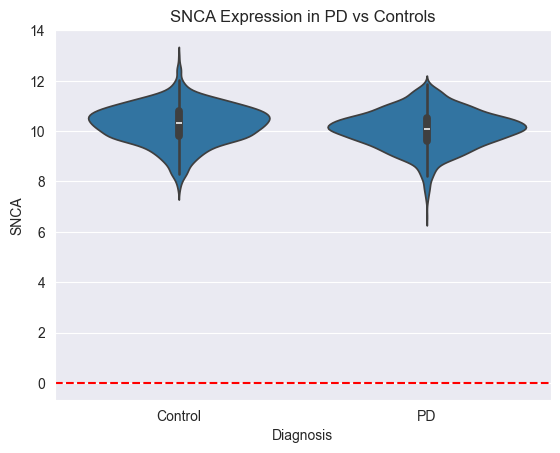

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='SNCA', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("SNCA Expression in PD vs Controls")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/3429726190.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'SNCA Expression in PD vs Controls')

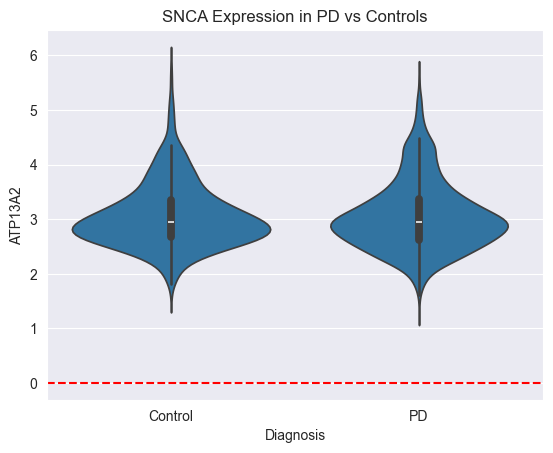

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='ATP13A2', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("ATP13A2 Expression in PD vs Controls")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/2045422596.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'PINK1 Expression in PD vs Controls')

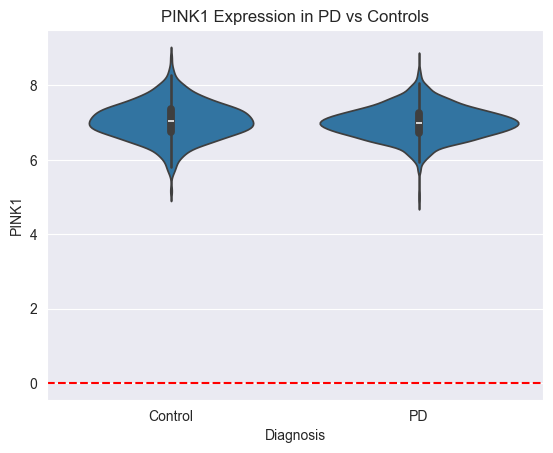

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='PINK1', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("PINK1 Expression in PD vs Controls")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/3231084407.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'UCHL1 Expression in PD vs Controls')

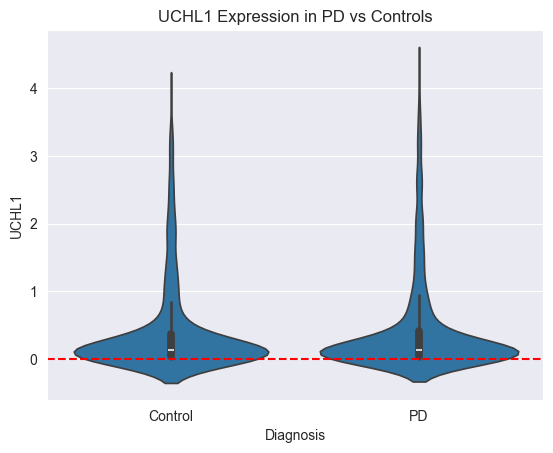

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='UCHL1', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("UCHL1 Expression in PD vs Controls")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/1437877159.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'LRRK2 Expression in PD vs Controls')

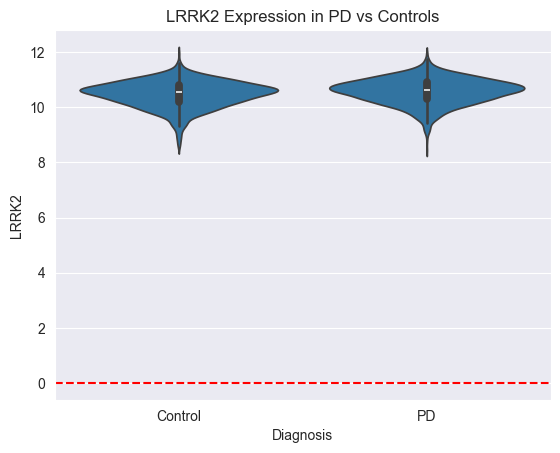

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='LRRK2', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("LRRK2 Expression in PD vs Controls")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/3461703367.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'FBXO7 Expression in PD vs Controls')

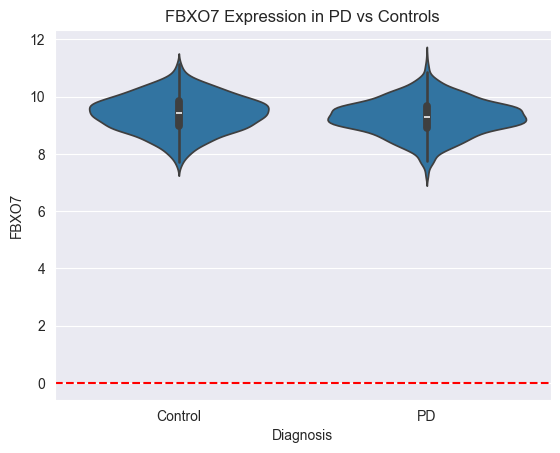

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='FBXO7', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("FBXO7 Expression in PD vs Controls")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_17678/218761603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()


Text(0.5, 1.0, 'PLA2G6 Expression in PD vs Controls')

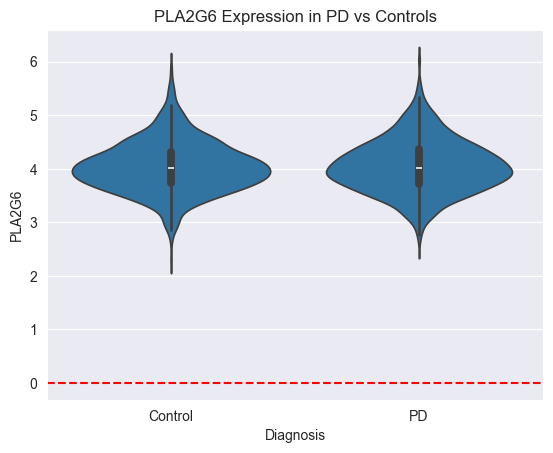

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
merged_obs_df_pd_ctrl = merged_obs_df[merged_obs_df['Diagnosis'].isin(['PD', 'Control'])]
merged_obs_df_pd_ctrl['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis'].cat.remove_unused_categories()
expression_data = merged_obs_df_pd_ctrl.iloc[:,:7]
expression_data['Diagnosis'] = merged_obs_df_pd_ctrl['Diagnosis']
sns.violinplot(x='Diagnosis', y='PLA2G6', data=expression_data)
plt.axhline(y=0, color='r', linestyle='--')  # Expected male baseline
plt.title("PLA2G6 Expression in PD vs Controls")